In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import classification_report
from tensorflow.keras import models, layers, callbacks

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [3]:
base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia"
train_path = os.path.join(base_path, "chest_xray", "train")

print(path)
print(os.listdir(path))

/kaggle/input/chest-xray-pneumonia
['chest_xray']


Step 1: Machine Learning Models

Task 1.1 — Load and Explore

In [4]:
train_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"

data = []

for label in ["NORMAL", "PNEUMONIA"]:
    folder_path = os.path.join(train_path, label)

    for img in os.listdir(folder_path):
        data.append([img, label])

df = pd.DataFrame(data, columns=["Image", "Label"])

df.head()

,Image,Label
0,NORMAL2-IM-0771-0001.jpeg,NORMAL
1,NORMAL2-IM-1294-0001-0002.jpeg,NORMAL
2,IM-0675-0001.jpeg,NORMAL
3,NORMAL2-IM-1169-0001.jpeg,NORMAL
4,IM-0421-0001.jpeg,NORMAL


In [5]:
df.shape

(5216, 2)

In [6]:
df.isnull().sum()

,0
Image,0
Label,0


In [7]:
df["Label"].value_counts()

,count
Label,
PNEUMONIA,3875
NORMAL,1341


In [8]:
counts = df["Label"].value_counts()

if abs(counts.iloc[0] - counts.iloc[1]) > 500:
    print("Use F1-score as main evaluation metric")

Use F1-score as main evaluation metric


Task 1.2 — Prepare the Data

In [9]:
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4172, 1)
(1044, 1)
(4172,)
(1044,)


Task 1.3 — Train and Compare Models

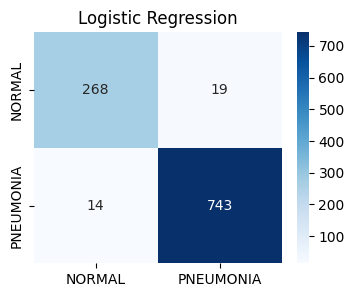

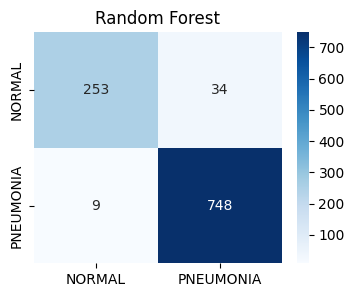

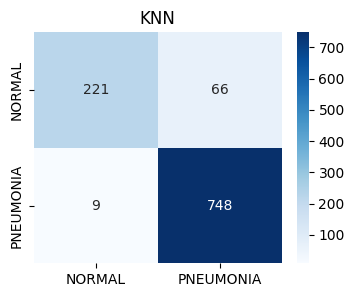

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression     0.968      0.975   0.982     0.978
1        Random Forest     0.959      0.957   0.988     0.972
2                  KNN     0.928      0.919   0.988     0.952

Best Model: Logistic Regression
Choice: Logistic Regression was chosen because it has the highest F1-score, providing the best balance between precision and recall for medical diagnosis.


In [10]:
def get_pixels(names, labels, path):
    data = []
    for n, l in zip(names, labels):
        img = cv2.imread(os.path.join(path, l, n), cv2.IMREAD_GRAYSCALE)
        data.append(cv2.resize(img, (64, 64)).flatten())
    return np.array(data) / 255.0

X_train_p = get_pixels(X_train['Image'], y_train, train_path)
X_test_p = get_pixels(X_test['Image'], y_test, train_path)

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("KNN", KNeighborsClassifier())
]

results = []

for name, model in models:
    model.fit(X_train_p, y_train)
    y_pred = model.predict(X_test_p)
    rep = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": rep['accuracy'],
        "Precision": rep['PNEUMONIA']['precision'],
        "Recall": rep['PNEUMONIA']['recall'],
        "F1-score": rep['PNEUMONIA']['f1-score']
    })

    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.title(name)
    plt.show()

summary_df = pd.DataFrame(results).round(3)
print(summary_df)

best = summary_df.loc[summary_df['F1-score'].idxmax(), 'Model']
print(f"\nBest Model: {best}")
print(f"Choice: {best} was chosen because it has the highest F1-score, providing the best balance between precision and recall for medical diagnosis.")

Step 2: Neural Network

Task 2.1 — Build and Train

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7684 - loss: 0.5068 - val_accuracy: 0.8886 - val_loss: 0.2797
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8957 - loss: 0.2566 - val_accuracy: 0.9210 - val_loss: 0.2116
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9170 - loss: 0.2127 - val_accuracy: 0.9377 - val_loss: 0.1577
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9221 - loss: 0.1950 - val_accuracy: 0.9305 - val_loss: 0.1774
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9275 - loss: 0.1999 - val_accuracy: 0.9425 - val_loss: 0.1428
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9197 - loss: 0.1994 - val_accuracy: 0.9365 - val_loss: 0.1780
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9386 - loss: 0.1758 - val_accuracy: 0.9341 - val_loss: 0.1528
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9419 - loss: 0.1532 - val_accu

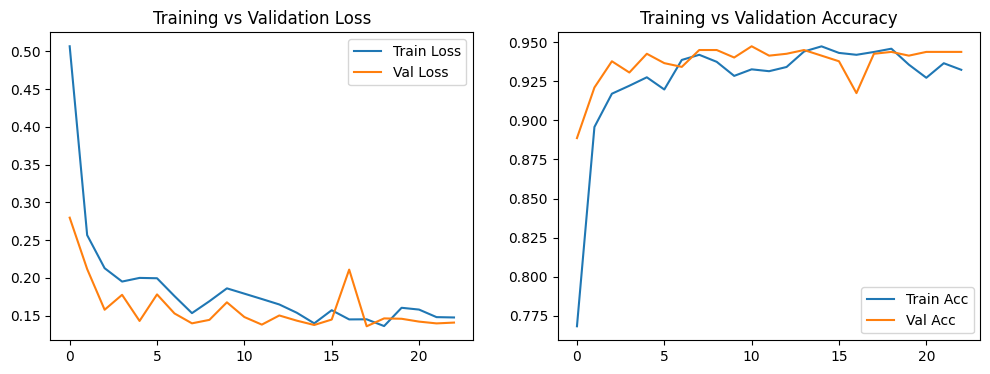

In [13]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

y_train_n = (y_train == "PNEUMONIA").astype(int)

model = Sequential([
    Input(shape=(4096,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_p, y_train_n,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

Task 2.2 — Compare with Step 1

In [14]:
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

y_test_n = (y_test == "PNEUMONIA").astype(int)
y_pred_ann = (model.predict(X_test_p) > 0.5).astype(int)
rep_ann = classification_report(y_test_n, y_pred_ann, output_dict=True)

ann_results = {
    "Model": "Neural Network (Base)",
    "Accuracy": rep_ann['accuracy'],
    "Precision": rep_ann['1']['precision'],
    "Recall": rep_ann['1']['recall'],
    "F1-score": rep_ann['1']['f1-score']
}

improved_model = Sequential([
    Input(shape=(4096,)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
improved_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
improved_model.fit(X_train_p, y_train_n, epochs=15, batch_size=32, verbose=0)

y_pred_imp = (improved_model.predict(X_test_p) > 0.5).astype(int)
rep_imp = classification_report(y_test_n, y_pred_imp, output_dict=True)

imp_results = {
    "Model": "Neural Network (Improved)",
    "Accuracy": rep_imp['accuracy'],
    "Precision": rep_imp['1']['precision'],
    "Recall": rep_imp['1']['recall'],
    "F1-score": rep_imp['1']['f1-score']
}

summary_df = pd.concat([summary_df, pd.DataFrame([ann_results, imp_results])], ignore_index=True).round(3)
print(summary_df)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
                       Model  Accuracy  Precision  Recall  F1-score
0        Logistic Regression     0.968      0.975   0.982     0.978
1              Random Forest     0.959      0.957   0.988     0.972
2                        KNN     0.928      0.919   0.988     0.952
3      Neural Network (Base)     0.961      0.960   0.987     0.973
4  Neural Network (Improved)     0.966      0.977   0.975     0.976


-The improved model achieved a leap in performance and reached an accuracy of 96.6%, which is very close to the best model (Logistic Regression).